# Hospital Readmissions Analysis and Predictive Modeling

Project objective: To develop a robust machine learning predictor for readmission risk among hospital patients. 

Methology: I preformed an interative model selection process, comparing Multiple Logistic Regression, Random Forests, and GXBoosting utilizing multiple dataset alterations. 

* Performance: Accuracy was limited to  70% with the current dataset
* Top predictors: Using P-value analysis (p<0.01) and feature importance, two variables were identified as primary drivers of risk:
    1. Age: How old a patient is
    2. ChronicDiseaseCount: The number of disease a patients have that are continous.
    3. 
* Error Audit: The model held a large number of false negaties and false positves, which indicates an issue with predicton power. As a majority of the patients were withing the non readmissioned group, the data seemed to be too reliant of that fact. 

Research Limitations & Omitted Variables: As the data seemed to be inconsistent patient to patient, a value of 0 for categories such as HeartRateMean often indicated a lack of record for said patients. Causing issues not only in the training of a model, but also in the test of said model to determine accuracy. When corrected the data lacked the ability to be significant in number of observations, hence the analysis and prediction was still run with the transparency with inconsistency. 

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("C://ProgramData//MySQL//MySQL Server 8.0//Uploads//Health_reduced.csv")
df.head()
# Readmission 1 is 'Yes this patient returned back within 90 days' and 0 is 'No this patient did not return within 90 days. 

,Age,ChronicDiseaseCount,LengthOfStay,BMIMean,BPDiastolicMean,BPSystolicMean,TemperatureMean,HeartRateMean,PulseRateMean,RespiratoryRateMean,...,BetaBlockers,Diuretics,TotalMedicine,CardiacTroponin,Hemoglobin,SerumSodium,SerumCreatinine,BNP,NT-proBNP,90Day_Readmission
0,58,18,3,51.48,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,...,0,0,0,0.0,0.00,0.0,0.00,0.0,0.0,1
1,80,24,6,31.74,63.052632,109.080000,98.266667,68.0,0.00000,17.833333,...,1,5,8,0.0,0.00,0.0,1.54,0.0,0.0,0
2,63,11,8,0.00,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,...,1,1,2,0.0,10.20,0.0,0.00,0.0,0.0,0
3,73,8,4,20.55,115.000000,182.000000,97.700000,0.0,0.00000,22.000000,...,0,0,0,0.0,0.00,132.0,0.00,0.0,0.0,0
4,85,20,3,0.00,59.044118,124.863636,97.854286,0.0,91.47619,17.000000,...,0,0,0,0.0,7.26,0.0,0.00,0.0,0.0,0


In [4]:
# Checking for null values before conducting any calculations
print(df.isnull().sum())

Age                    0
ChronicDiseaseCount    0
LengthOfStay           0
BMIMean                0
BPDiastolicMean        0
BPSystolicMean         0
TemperatureMean        0
HeartRateMean          0
PulseRateMean          0
RespiratoryRateMean    0
ACEInhibitors          0
ARBs                   0
BetaBlockers           0
Diuretics              0
TotalMedicine          0
CardiacTroponin        0
Hemoglobin             0
SerumSodium            0
SerumCreatinine        0
BNP                    0
NT-proBNP              0
90Day_Readmission      0
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 

In [6]:
# seperating response variable and predictors
y = df['90Day_Readmission']
X = df.drop('90Day_Readmission', axis = 1)

In [7]:
# Split into training and tesst sets (Y: 0 = Not Readmissioned within 90 Days, 1 = Readmissioned within 90 days)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Train the multiple logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

#Evaluate accuracy
accuracy = model.score(X_test_scaled, y_test)
print(f"The model's accuracy on unseen data is: {accuracy: .2%}")

The model's accuracy on unseen data is:  70.54%


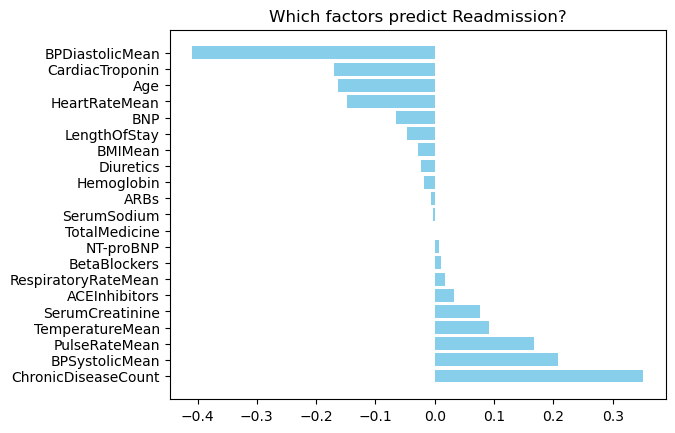

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtain coefficients of importance
importance = model.coef_[0]
feature_names = X.columns

# Create a dataframe for easy plotting 
feature_importance = pd.DataFrame({'Feature':feature_names, 'Importance':importance})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

# Plotting
plt.figure(figure = (10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color = 'skyblue')
plt.title('Which factors predict Readmission?')
plt.show()

In [9]:
import statsmodels.api as sm

# Covert the scaled arracy bacck into a dataframe with original names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X.columns)

#Add a constant (intercept)
X_train_const = sm.add_constant(X_train_scaled_df)

#Fit the logit model 
logit_model = sm.Logit(y_train.reset_index(drop = True), X_train_const)
result = logit_model.fit()

# Print summary to interpret p-values
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.598886
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:      90Day_Readmission   No. Observations:                 6784
Model:                          Logit   Df Residuals:                     6763
Method:                           MLE   Df Model:                           20
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                 0.03079
Time:                        14:13:22   Log-Likelihood:                -4062.8
converged:                       True   LL-Null:                       -4191.9
Covariance Type:            nonrobust   LLR p-value:                 2.597e-43
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.8446      0.027    -30.789      0.000      -0.898      -0.791
A

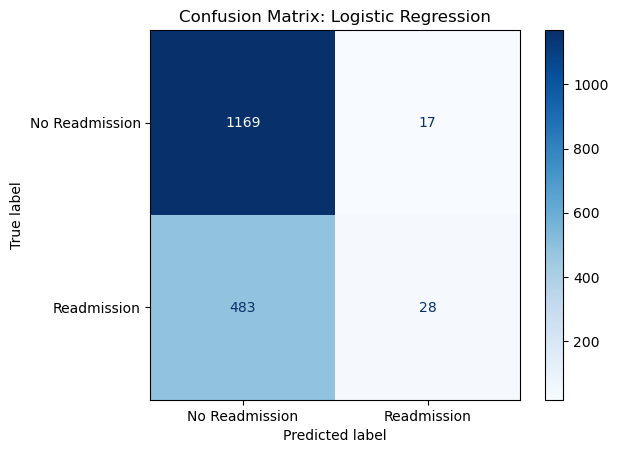

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it visually
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No Readmission','Readmission'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [11]:
path = "C://ProgramData//MySQL//MySQL Server 8.0//Uploads//significant_variables.csv"
df_2 = pd.read_csv(path)
df_2.head()

,Age,ChronicDiseaseCount,BPDiastolicMean,HeartRateMean,PulseRateMean,SerumCreatinine,90Day_Readmission
0,58,18,0.000000,0.0,0.00000,0.00,1
1,80,24,63.052632,68.0,0.00000,1.54,0
2,63,11,0.000000,0.0,0.00000,0.00,0
3,73,8,115.000000,0.0,0.00000,0.00,0
4,85,20,59.044118,0.0,91.47619,0.00,0


In [12]:
# Remake the model to determine accuracy
y = df_2['90Day_Readmission']
X = df_2.drop('90Day_Readmission', axis = 1)

# Split into training and tesst sets (Y: 0 = Not Readmissioned within 90 Days, 1 = Readmissioned within 90 days)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Train the multiple logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

#Evaluate accuracy
accuracy = model.score(X_test_scaled, y_test)
print(f"The model's accuracy on unseen data is: {accuracy: .2%}")

The model's accuracy on unseen data is:  70.12%


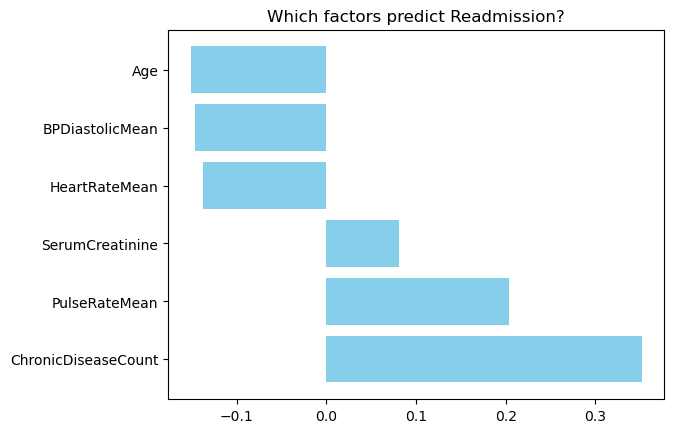

In [13]:
importance = model.coef_[0]
feature_names = X.columns

# Create a dataframe for easy plotting 
feature_importance = pd.DataFrame({'Feature':feature_names, 'Importance':importance})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

# Plotting
plt.figure(figure = (10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color = 'skyblue')
plt.title('Which factors predict Readmission?')
plt.show()

In [14]:
# Covert the scaled arracy bacck into a dataframe with original names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X.columns)

#Add a constant (intercept)
X_train_const = sm.add_constant(X_train_scaled_df)

#Fit the logit model 
logit_model = sm.Logit(y_train.reset_index(drop = True), X_train_const)
result = logit_model.fit()

# Print summary to interpret p-values
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.599982
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      90Day_Readmission   No. Observations:                 6784
Model:                          Logit   Df Residuals:                     6777
Method:                           MLE   Df Model:                            6
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                 0.02902
Time:                        14:13:26   Log-Likelihood:                -4070.3
converged:                       True   LL-Null:                       -4191.9
Covariance Type:            nonrobust   LLR p-value:                 1.124e-49
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.8388      0.027    -30.987      0.000      -0.892      -0.786
Ag

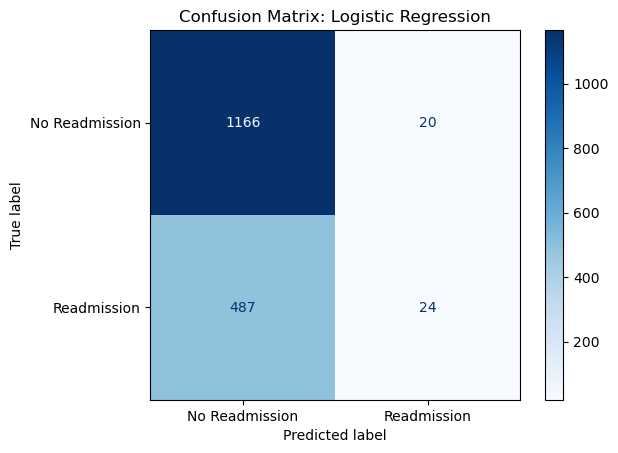

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it visually
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No Readmission','Readmission'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

Both Logistic regression models hold an approximately 70% accuracy rating, yet healthy are skewed to predicting no readmission within 90 days. From my SQL query a majority of patients were Readmissioned within 90 days. Approximately 69% of the 8481 patients do not return within 90 days and approximately 30% return within 90 days. 

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Fit the model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# Check Accurary 
rf_accuracy = rf_model.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_accuracy: .2%}")
print(f"Logistic Regression Accuracy: 70.12%")

Random Forest Accuracy:  66.94%
Logistic Regression Accuracy: 70.12%


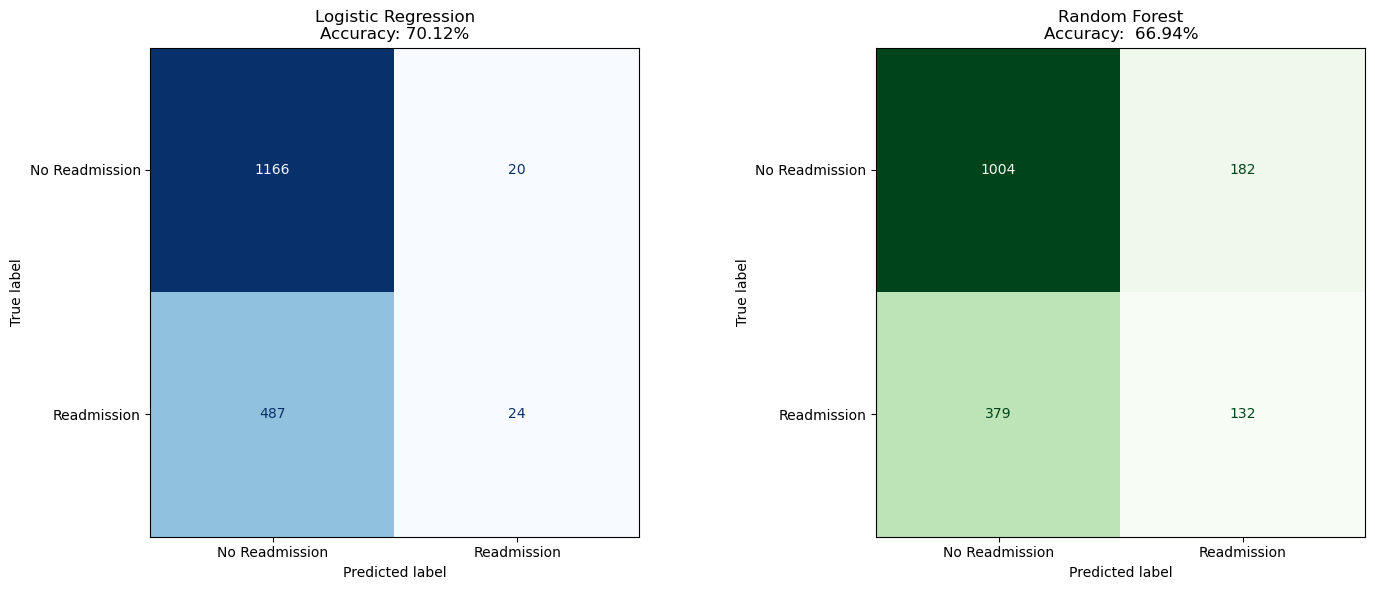

In [17]:
# Get predictions for both models
y_pred_logit = model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

#Create the confusion matrices 
cm_logit = confusion_matrix(y_test, y_pred_logit)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# set up the plotting area 
fig, ax = plt.subplots(1,2, figsize = (15, 6))

# Plot Logistic Regression Matrix
disp_logit = ConfusionMatrixDisplay(confusion_matrix = cm_logit, display_labels = ['No Readmission','Readmission'])
disp_logit.plot(ax=ax[0], cmap = 'Blues', colorbar = False)
ax[0].set_title(f'Logistic Regression\nAccuracy: 70.12%')

# Plot Random Forest Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix = cm_rf, display_labels = ['No Readmission','Readmission'])
disp_rf.plot(ax = ax[1], cmap = 'Greens', colorbar = False)
ax[1].set_title(f'Random Forest\nAccuracy: {rf_model.score(X_test, y_test): .2%}')

plt.tight_layout()
plt.show()

In [18]:
df = pd.read_csv("C://ProgramData//MySQL//MySQL Server 8.0//Uploads//Health_reduced.csv")
# seperating response variable and predictors
y = df['90Day_Readmission']
X = df.drop('90Day_Readmission', axis = 1)
# Split into training and tesst sets (Y: 0 = Not Readmissioned within 90 Days, 1 = Readmissioned within 90 days)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

# Initialize and Fit the model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# Check Accurary 
rf_accuracy = rf_model.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_accuracy: .2%}")


Random Forest Accuracy:  70.18%


In [19]:
X_train

,Age,ChronicDiseaseCount,LengthOfStay,BMIMean,BPDiastolicMean,BPSystolicMean,TemperatureMean,HeartRateMean,PulseRateMean,RespiratoryRateMean,...,ARBs,BetaBlockers,Diuretics,TotalMedicine,CardiacTroponin,Hemoglobin,SerumSodium,SerumCreatinine,BNP,NT-proBNP
7510,86,13,16,34.68,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0.000,0.0,0.000000,0.000,0.0,0.0
6586,58,18,5,36.56,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0.000,0.0,0.000000,0.000,0.0,0.0
2729,87,11,2,0.00,67.437500,107.111111,98.735000,0.000000,71.333333,15.142857,...,0,1,1,2,0.017,0.0,0.000000,0.000,0.0,0.0
4204,72,10,4,25.84,75.350000,154.500000,97.981818,79.812500,0.000000,18.000000,...,0,2,0,4,0.000,0.0,138.666667,0.000,0.0,0.0
6662,73,9,4,28.70,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0.000,0.0,0.000000,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,74,11,5,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0.000,0.0,0.000000,0.000,0.0,0.0
5191,68,16,3,43.06,71.333333,117.578947,98.000000,79.083333,0.000000,18.000000,...,0,1,2,3,0.000,0.0,0.000000,1.075,0.0,0.0
5390,92,10,8,24.02,65.666667,118.666667,0.000000,0.000000,0.000000,17.000000,...,1,1,0,2,0.000,0.0,0.000000,3.100,0.0,0.0
860,76,14,8,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0.000,0.0,0.000000,0.000,0.0,0.0


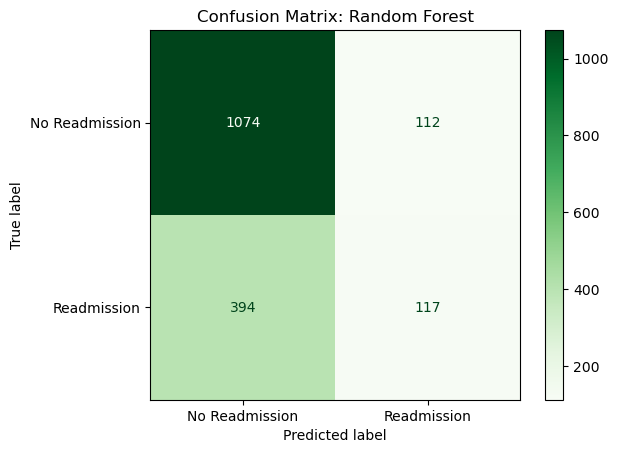

In [20]:
y_pred_rf = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Random Forest Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix = cm_rf, display_labels = ['No Readmission','Readmission'])
disp_rf.plot(cmap = 'Greens')
plt.title('Confusion Matrix: Random Forest')
plt.show()

removing non significant variables actually lowered accuracy insignificantly from 70.53% to 70.12%, running the random forest with only significant variables lowered the accuracy even more from 70.12% to 66.94%, but once reintroducing all variables to the random forest model the accuracy then increased to 70.18%, but not has a lower bias in guessing non readmission. 

In [21]:
#importance of random forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Dataframe for ranking
rf_importance = pd.DataFrame({'Feature': feature_names, 'Importance':importances})

#sort importance
rf_importance = rf_importance.sort_values(by='Importance', ascending = False)

# Display the Top 15
print(rf_importance.head(15))

                Feature  Importance
0                   Age    0.169718
1   ChronicDiseaseCount    0.125931
2          LengthOfStay    0.124001
3               BMIMean    0.091534
5        BPSystolicMean    0.059447
4       BPDiastolicMean    0.059301
9   RespiratoryRateMean    0.055150
6       TemperatureMean    0.053822
18      SerumCreatinine    0.045368
8         PulseRateMean    0.036297
17          SerumSodium    0.028151
14        TotalMedicine    0.027333
16           Hemoglobin    0.023983
7         HeartRateMean    0.022952
15      CardiacTroponin    0.022128


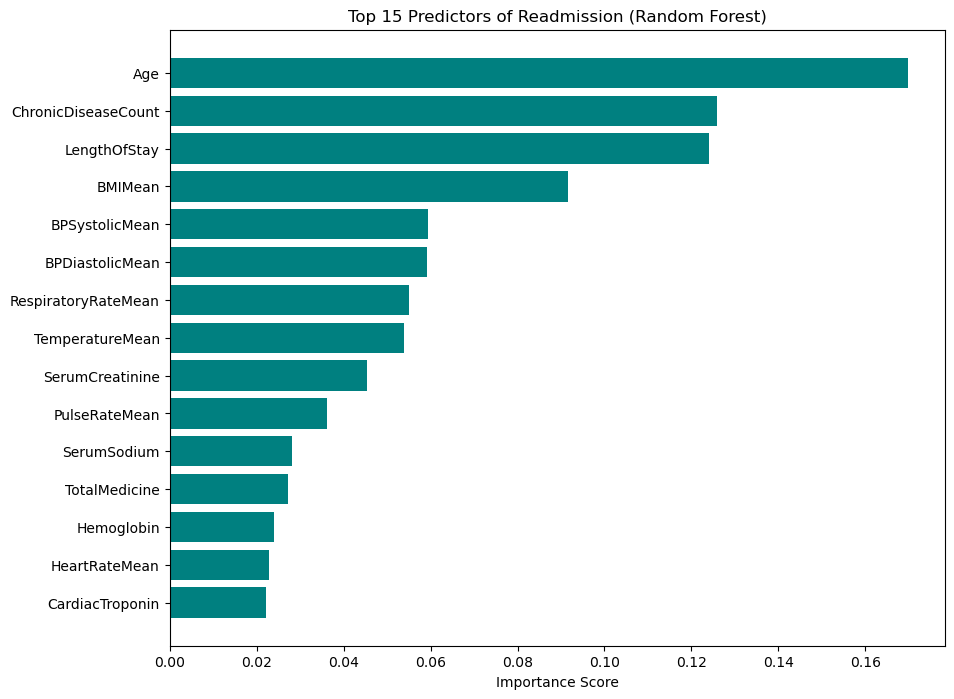

In [22]:
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'].head(15), rf_importance['Importance'].head(15), color='teal')
plt.xlabel('Importance Score')
plt.title('Top 15 Predictors of Readmission (Random Forest)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

In [23]:
import xgboost as xgb
from sklearn.metrics import classification_report

In [24]:
# Initialize the model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,      
    max_depth=5,            
    scale_pos_weight=2.2, 
    eval_metric='logloss'
)

# Fit the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

In [25]:
print(confusion_matrix(y_test, y_pred))

[[778 408]
 [266 245]]


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70      1186
           1       0.38      0.48      0.42       511

    accuracy                           0.60      1697
   macro avg       0.56      0.57      0.56      1697
weighted avg       0.63      0.60      0.61      1697



The model is holds 75% accuracy is correctly predicting non readmission patients, 38% accurate in predicting readmission patients, and hold 60% accuracy overall. Due to the nature of these findings, I am shifting from classification to determining probabities.

In [27]:
# probabilities
y_probs = xgb_model.predict_proba(X_test)[:,1]

# determining risk
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Prob': y_probs
})

In [28]:
import numpy as np
from sklearn.metrics import accuracy_score

# strict threshold due to prediction issues
custom_threshold = 0.70
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"Custom Accuracy: {accuracy_score(y_test, y_pred_custom)}")
print(confusion_matrix(y_test, y_pred_custom))

Custom Accuracy: 0.7118444313494402
[[1161   25]
 [ 464   47]]


Even when being more reliant on probabilites, the model is unable to correct identify each group to a significant degree. the final model, inaccurately identified 28% of non readmissioned patients and 34% of readmissioned patients. 

In [29]:
def readmission_risk_calc(patient_data):
    patient_df = pd.DataFrame([patient_data])
    probability = xgb_model.predict_proba(patient_df)[0][1]
    return probability

After further analysis I then began to realize that the models are heavily reliant of age as a means of prediction, yet, a majority of the patients in the dataset are 60 through 89, signifying that prediction errors are not a consequence of method but an issue of representation. Therefore, now I attempt to recreate the original model with a subset of the data that have a significant amount of patients in their group. 

In [30]:
df = pd.read_csv("C://Users//Nicho//OneDrive//Desktop//PowerBI//Data_altered.csv")
df.head()

,Age,ChronicDiseaseCount,BPDiastolicMean,HeartRateMean,PulseRateMean,SerumCreatinine,Readmission_in90
0,80,24,63.052632,68.0,0.00000,1.54,0
1,63,11,0.000000,0.0,0.00000,0.00,0
2,73,8,115.000000,0.0,0.00000,0.00,0
3,85,20,59.044118,0.0,91.47619,0.00,0
4,83,9,0.000000,0.0,0.00000,0.00,1


In [37]:
X = df.drop('Readmission_in90', axis = 1)
y = df['Readmission_in90']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state =42)

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# train new models
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
accuracy = model.score(X_test_scaled, y_test)
print(f"The model's accuracy on unseen data is: {accuracy: .2%}")

The model's accuracy on unseen data is:  70.99%


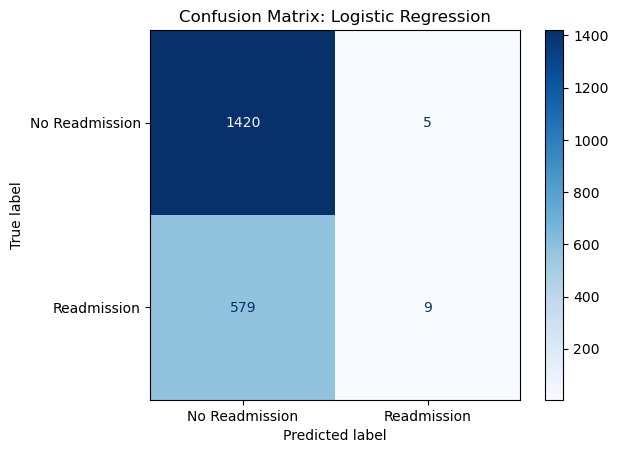

In [39]:
# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it visually
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No Readmission','Readmission'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [40]:
# Initialize and Fit the model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# Check Accurary 
rf_accuracy = rf_model.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_accuracy: .2%}")
print(f"Logistic Regression Accuracy: 70.12%")

Random Forest Accuracy:  67.81%
Logistic Regression Accuracy: 70.12%


In [41]:
X_train.head()

,Age,ChronicDiseaseCount,BPDiastolicMean,HeartRateMean,PulseRateMean,SerumCreatinine
6131,73,9,0.000000,0.0,0.0,0.0
5194,79,14,0.000000,0.0,0.0,0.0
3263,65,15,0.000000,0.0,0.0,0.0
3150,86,7,0.000000,0.0,0.0,0.0
3935,77,14,61.529412,0.0,0.0,0.0


# Concluding remarks:

The final analysis indicates that while a predictive model can be established, it is limited to an accuracy of approximately 70% given the current dataset. A significant challenge remains regarding False Negatives, which suggests the model may under-predict readmission risks in certain cases.

Furthermore, data quality issues, such as 'placeholder' or missing values (Mean Heart Rate recorded as 0), introduce noise that hinders the algorithm's predictive power. To improve the reliability of the Risk Calculator, future iterations require more robust data collection and a larger sample size for younger demographics to ensure model completeness. Consequently, this project serves as a foundational proof-of-concept for a geriatric-focused risk tool.